# Strategy evidence synthesis

**Objective.** Consolidate the completed strategy chain into one aggregate-only
evidence hierarchy before Gate F1, refreshed through Notebook 48. The notebook
asks two bounded questions:

1. Which strategy is a defensible working base once evidence quality is considered?
2. Does any sentiment-enhanced rule earn promotion over that base?

This notebook loads only aggregate CSV/JSON artifacts. It does **not** load prices,
returns, positions, headlines, or licensed text, and it does not search parameters.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SEED = 20260805
np.random.seed(SEED)

ROOT = Path.cwd()
if not (ROOT / "final_experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "final_experiments").exists(), "Run from the repository root or final_experiments/."

OUTPUT = ROOT / "final_experiments/outputs/44_strategy_evidence_synthesis"
OUTPUT.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 100)


def read_csv(relative: str) -> pd.DataFrame:
    path = ROOT / relative
    assert path.suffix == ".csv", f"Aggregate-only boundary violated: {path}"
    return pd.read_csv(path)


def read_json(relative: str) -> dict:
    path = ROOT / relative
    assert path.suffix == ".json", f"Aggregate-only boundary violated: {path}"
    return json.loads(path.read_text())


def sha256(relative: str) -> str:
    path = ROOT / relative
    return hashlib.sha256(path.read_bytes()).hexdigest()


def one(frame: pd.DataFrame, **filters: object) -> pd.Series:
    mask = pd.Series(True, index=frame.index)
    for column, value in filters.items():
        mask &= frame[column].eq(value)
    selected = frame.loc[mask]
    assert len(selected) == 1, f"Expected one row for {filters}; found {len(selected)}"
    return selected.iloc[0]


def git_commit() -> str:
    return subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()

## Frozen decision policy

The ordinal evidence score below is a display aid, not a statistical weight:

- **5** — independent, price-only benchmark fitted before evaluation;
- **4** — frozen chronological or external-time test;
- **3** — frozen cross-period stress test with a previously opened research chain;
- **2** — bounded retrospective robustness on an opened outcome window;
- **1** — explicitly post-result diagnostic.

A sentiment rule can be promoted only if its paired net-return interval excludes zero
in the favourable direction, its effect is temporally stable, its local predeclared
gate passes, and its evidence score is at least 4. A high retrospective Sharpe cannot
compensate for failing those conditions. The sentiment-free HAR target is assessed as
a conventional research benchmark, not as a claim of sentiment alpha or a
deployment-qualified strategy. Notebook 46's external-time transfer is binding for
any claim that the base itself is stable.

In [2]:
paths = {
    "n20_results": "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/results.csv",
    "n20_gates": "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/gates.csv",
    "n21_results": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/strategy_results.csv",
    "n21_gates": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/gates.csv",
    "n21_inference": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/strategy_inference.csv",
    "n23_results": "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/results.csv",
    "n23_gates": "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/gates.csv",
    "n24_results": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/results.csv",
    "n24_gates": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/gates.csv",
    "n24_inference": "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/paired_inference.csv",
    "n25_results": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/results.csv",
    "n25_gates": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/gates.csv",
    "n25_inference": "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/paired_inference.csv",
    "n26_results": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/results.csv",
    "n26_gates": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/gates.csv",
    "n26_inference": "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/paired_inference.csv",
    "n27_results": "final_experiments/outputs/27_fnspid_har_sentiment_composition/results.csv",
    "n27_gates": "final_experiments/outputs/27_fnspid_har_sentiment_composition/gates.csv",
    "n27_inference": "final_experiments/outputs/27_fnspid_har_sentiment_composition/paired_inference.csv",
    "n36_result": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/hybrid_result.csv",
    "n36_gates": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/gates.csv",
    "n40_results": "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/strategy_results.csv",
    "n40_gates": "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/gates.csv",
    "n42_results": "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/strategy_results.csv",
    "n42_gates": "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/gates.csv",
    "n43_results": "final_experiments/outputs/43_lseg_gemma_story_family_first_release/strategy_results.csv",
    "n43_inference": "final_experiments/outputs/43_lseg_gemma_story_family_first_release/inference.csv",
    "n46_results": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/strategy_results.csv",
    "n46_gates": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/gates.csv",
    "n46_inference": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/paired_inference.csv",
    "n46_forecast_inference": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/forecast_inference.csv",
    "n47_results": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/results.csv",
    "n47_gates": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/gates.csv",
    "n47_inference": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/inference.csv",
    "n48_results": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/results.csv",
    "n48_gates": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/gates.csv",
    "n48_inference": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/inference.csv",
}

tables = {name: read_csv(path) for name, path in paths.items()}
source_files = pd.DataFrame(
    [{"source": name, "path": path, "sha256": sha256(path)} for name, path in paths.items()]
)
assert source_files["path"].str.endswith((".csv", ".json")).all()
source_files.to_csv(OUTPUT / "source_files.csv", index=False)

display(Markdown(f"Loaded **{len(source_files)} aggregate artifacts**; no row-level return or text file was read."))

Loaded **37 aggregate artifacts**; no row-level return or text file was read.

## Strategy evidence registry

Raw Sharpe ratios are shown, but the rows are not treated as one commensurate horse
race: universes, dates, costs, and selection histories differ. `promotion_pass` applies
the rule-specific gate in the source notebook. `decision_eligible` applies the stricter
cross-notebook evidence policy declared above.

In [3]:
n20_hyst = one(tables["n20_results"], split="evaluation", arm="hysteresis")
n21_har = one(tables["n21_results"], arm="control_har_target")
n21_sent = one(tables["n21_results"], arm="sentiment_har_target")
n23_sent = one(tables["n23_results"], arm="trend_200_har_sentiment")
n24_product = one(tables["n24_results"], arm="har_sentiment")
n25_product = one(tables["n25_results"], arm="walkforward_har_sentiment")
n26_brake = one(tables["n26_results"], period="full", arm="firm_brake")
n27_cap = one(tables["n27_results"], era="evaluation", arm="absolute_cap")
n36_hybrid = tables["n36_result"].iloc[0]
n40_eval = one(tables["n40_results"], split="evaluation", strategy="adaptive_dispersion")
n42_adaptive = one(tables["n42_results"], strategy="adaptive_dispersion")
n43_filtered = one(tables["n43_results"], strategy="first_release_only")
n46_har = one(tables["n46_results"], arm="frozen_har")
n46_constant = one(tables["n46_results"], arm="constant_matched_har")
n46_overlay = one(tables["n46_results"], arm="har_gemma_breadth_overlay")
n47_revision = one(tables["n47_results"], arm="revision_delta")
n47_level = one(tables["n47_results"], arm="matched_latest_level")
n48_event = one(tables["n48_results"], arm="one_session_event")
n48_state = one(tables["n48_results"], arm="persistent_state")


def registry_row(
    notebook: int,
    strategy: str,
    regime: str,
    sentiment_role: str,
    row: pd.Series,
    evidence_class: str,
    evidence_score: int,
    local_gate_pass: bool,
    decision_eligible: bool,
    decision: str,
    total_return_field: str = "total_return_net",
) -> dict:
    return {
        "notebook": notebook,
        "strategy": strategy,
        "regime": regime,
        "sentiment_role": sentiment_role,
        "gross_sharpe": float(row["sharpe_gross"]),
        "net_sharpe": float(row["sharpe_net"]),
        "net_total_return": float(row[total_return_field]),
        "max_drawdown": float(row["max_drawdown"]),
        "breakeven_bps_per_side": float(row.get("breakeven_bps_per_side", np.nan)),
        "evidence_class": evidence_class,
        "evidence_score": evidence_score,
        "local_gate_pass": bool(local_gate_pass),
        "decision_eligible": bool(decision_eligible),
        "decision": decision,
    }


registry = pd.DataFrame(
    [
        registry_row(
            21, "Sentiment-free HAR target", "FNSPID 2020–2023", "none", n21_har,
            "independent price-only benchmark", 5, True, True, "retain as research benchmark",
        ),
        registry_row(
            21, "Sentiment-augmented HAR target", "FNSPID 2020–2023", "variance feature", n21_sent,
            "frozen chronological comparison", 4,
            bool(tables["n21_gates"].iloc[0]["useful_risk_gate"]), False, "reject increment",
        ),
        registry_row(
            20, "Market-pressure hysteresis", "FNSPID 2020–2023", "market exposure brake", n20_hyst,
            "opened-chain chronological result", 3,
            bool(one(tables["n20_gates"], arm="hysteresis")["useful_risk_overlay_gate"]), False,
            "future risk hypothesis only",
        ),
        registry_row(
            23, "Trend × HAR × sentiment", "FNSPID 2020–2023", "market exposure brake", n23_sent,
            "bounded post-result base comparison", 2,
            bool(tables["n23_gates"].iloc[0]["useful_sentiment_gate"]), False, "reject base change",
        ),
        registry_row(
            24, "HAR × sentiment product", "FNSPID 2020–2023", "market exposure brake", n24_product,
            "bounded post-result composition", 2,
            bool(tables["n24_gates"].iloc[0]["useful_risk_gate"]), False,
            "freeze for genuinely new dates",
        ),
        registry_row(
            25, "Walk-forward HAR × sentiment", "FNSPID 2013–2019", "market exposure brake", n25_product,
            "cross-period prior-only stress test", 3,
            bool(tables["n25_gates"].iloc[0]["useful_risk_gate"]), False,
            "downside mechanism only",
        ),
        registry_row(
            26, "Gemma exact-negative firm brake", "LSEG 2025–2026", "firm exposure brake", n26_brake,
            "non-pooled retrospective robustness", 2,
            bool(tables["n26_gates"].iloc[0]["firm_useful_risk_gate"]), False,
            "downside mechanism only", total_return_field="total_return_net",
        ),
        registry_row(
            27, "HAR sentiment absolute cap", "FNSPID 2020–2023", "market exposure cap", n27_cap,
            "post-result operator diagnostic", 1,
            bool(tables["n27_gates"].iloc[0]["useful_risk_gate_both_eras"]), False,
            "reject operator change",
        ),
        registry_row(
            36, "Capped LSEG/Gemma hybrid", "LSEG 2025–2026", "cross-sectional long/short", n36_hybrid,
            "same-window retrospective audit", 1,
            bool(tables["n36_gates"].iloc[0]["factor_alpha_gate"]), False,
            "descriptive; factor gate fails", total_return_field="total_return_net",
        ),
        registry_row(
            40, "Portable continuous rule", "FNSPID 2020–2023", "cross-sectional long/short", n40_eval,
            "frozen cross-regime stress test", 3,
            bool(tables["n40_gates"].iloc[0]["deployment_gate"]), False,
            "gross signal; deployment fails", total_return_field="total_return_net",
        ),
        registry_row(
            42, "Portable continuous rule", "FNSPID 2010", "cross-sectional long/short", n42_adaptive,
            "external-time backward test", 4,
            bool(tables["n42_gates"].iloc[0]["replication_gate"]), False,
            "reject stable cross-era alpha", total_return_field="total_return_net",
        ),
        registry_row(
            43, "First-release continuous rule", "LSEG 2025–2026", "cross-sectional long/short", n43_filtered,
            "bounded retrospective direct replay", 2, False, False,
            "reject historical alpha", total_return_field="total_return_net",
        ),
        registry_row(
            46, "Frozen HAR target", "LSEG index 2025–2026", "none", n46_har,
            "external-time frozen-model transfer on an opened outcome family", 4,
            bool(tables["n46_gates"].iloc[0]["external_time_base_gate"]), False,
            "retain benchmark only; transfer gate fails",
        ),
        registry_row(
            46, "HAR × Gemma breadth", "LSEG index 2025–2026", "market exposure brake", n46_overlay,
            "post-research deterministic composition on an opened window", 2,
            bool(
                tables["n46_gates"].iloc[0]["overlay_return_gate"]
                or tables["n46_gates"].iloc[0]["overlay_useful_risk_gate"]
            ),
            False,
            "mechanical downside evidence; reject increment",
        ),
        registry_row(
            47, "Gemma story-revision delta", "LSEG 2025–2026", "cross-sectional long/short", n47_revision,
            "bounded post-result revision-information audit", 2,
            bool(tables["n47_gates"].iloc[0]["retrospective_strategy_gate"]), False,
            "gross revision information; 10-bps cost NO-GO",
        ),
        registry_row(
            48, "Persistent Gemma revision state", "LSEG 2025–2026", "cross-sectional long/short", n48_state,
            "input-gated post-result implementation audit", 1,
            bool(tables["n48_gates"].iloc[0]["retrospective_strategy_gate"]), False,
            "turnover improvement; 10-bps cost and stability NO-GO",
        ),
    ]
)

assert registry["decision_eligible"].sum() == 1
assert registry.loc[registry["decision_eligible"], "sentiment_role"].eq("none").all()
registry.to_csv(OUTPUT / "strategy_evidence_registry.csv", index=False)

display(
    registry[
        ["notebook", "strategy", "regime", "net_sharpe", "net_total_return", "evidence_score", "decision"]
    ].style.format({"net_sharpe": "{:.3f}", "net_total_return": "{:+.1%}"})
)

,notebook,strategy,regime,net_sharpe,net_total_return,evidence_score,decision
0,21,Sentiment-free HAR target,FNSPID 2020–2023,0.673,+29.8%,5,retain as research benchmark
1,21,Sentiment-augmented HAR target,FNSPID 2020–2023,0.673,+30.3%,4,reject increment
2,20,Market-pressure hysteresis,FNSPID 2020–2023,0.783,+63.6%,3,future risk hypothesis only
3,23,Trend × HAR × sentiment,FNSPID 2020–2023,0.677,+22.4%,2,reject base change
4,24,HAR × sentiment product,FNSPID 2020–2023,0.835,+35.2%,2,freeze for genuinely new dates
5,25,Walk-forward HAR × sentiment,FNSPID 2013–2019,1.164,+93.1%,3,downside mechanism only
6,26,Gemma exact-negative firm brake,LSEG 2025–2026,1.526,+10.3%,2,downside mechanism only
7,27,HAR sentiment absolute cap,FNSPID 2020–2023,0.769,+33.2%,1,reject operator change
8,36,Capped LSEG/Gemma hybrid,LSEG 2025–2026,2.271,+11.8%,1,descriptive; factor gate fails
9,40,Portable continuous rule,FNSPID 2020–2023,-1.103,-23.3%,3,gross signal; deployment fails


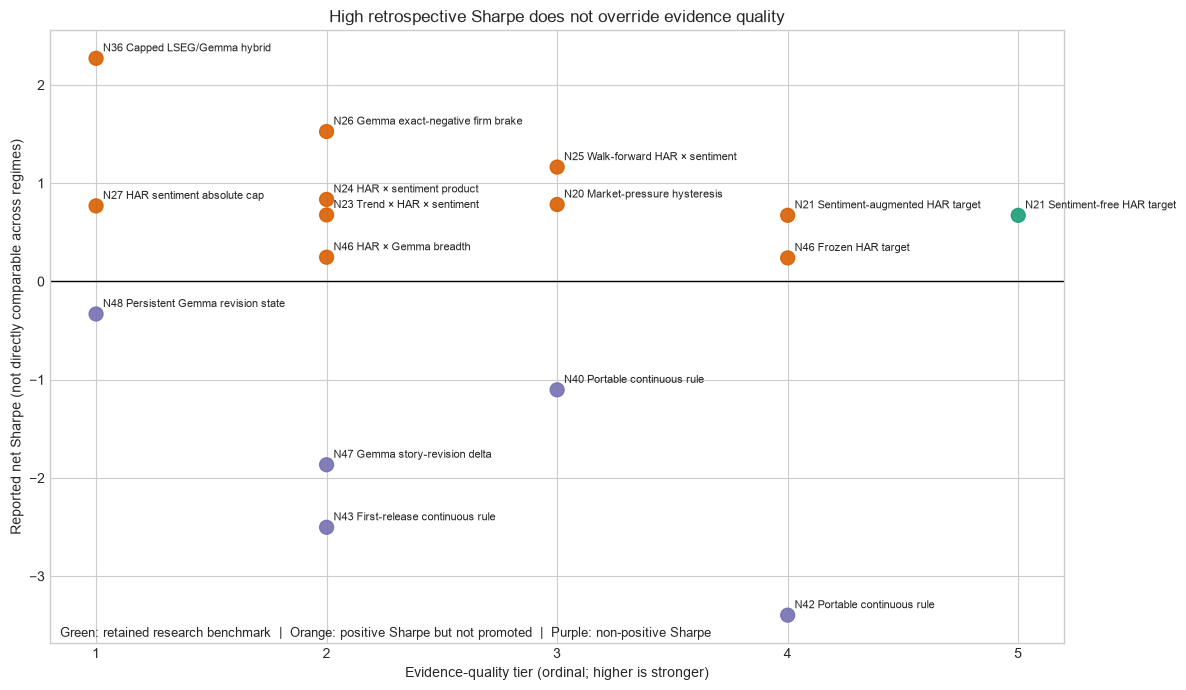

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = np.where(registry["decision_eligible"], "#1b9e77", np.where(registry["net_sharpe"] > 0, "#d95f02", "#7570b3"))
ax.scatter(registry["evidence_score"], registry["net_sharpe"], s=100, c=colors, alpha=0.9)
for _, row in registry.iterrows():
    ax.annotate(
        f"N{int(row['notebook'])} {row['strategy']}",
        (row["evidence_score"], row["net_sharpe"]),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )
ax.axhline(0, color="black", lw=1)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Evidence-quality tier (ordinal; higher is stronger)")
ax.set_ylabel("Reported net Sharpe (not directly comparable across regimes)")
ax.set_title("High retrospective Sharpe does not override evidence quality")
ax.text(
    0.01, 0.01,
    "Green: retained research benchmark  |  Orange: positive Sharpe but not promoted  |  Purple: non-positive Sharpe",
    transform=ax.transAxes, fontsize=9,
)
fig.tight_layout()
fig.savefig(OUTPUT / "evidence_quality_vs_net_sharpe.png", dpi=180, bbox_inches="tight")
plt.show()

## Paired sentiment-overlay scorecard

The return estimand is always challenger minus its local base. Downside rows preserve
the sign convention used in each source, but `downside_improves` translates them to one
common interpretation. These tests overlap in dates and strategy construction, so their
p-values are **not** combined into a meta-analysis.

In [5]:
n21_inf = tables["n21_inference"]
n24_inf = tables["n24_inference"]
n25_inf = tables["n25_inference"]
n26_inf = tables["n26_inference"]
n27_inf = tables["n27_inference"]
n46_inf = tables["n46_inference"]
n47_inf = tables["n47_inference"]
n48_inf = tables["n48_inference"]


def overlay_row(
    label: str,
    regime: str,
    challenger_sharpe: float,
    base_sharpe: float,
    mean: float,
    low: float,
    high: float,
    p_return: float,
    downside_p: float,
    downside_improves: bool,
    temporal_stable: bool,
    multiplicity: str,
) -> dict:
    return {
        "comparison": label,
        "regime": regime,
        "delta_net_sharpe": challenger_sharpe - base_sharpe,
        "return_difference_bps_session": 10_000 * mean,
        "return_ci_low_bps_session": 10_000 * low,
        "return_ci_high_bps_session": 10_000 * high,
        "return_p_two_sided": p_return,
        "return_ci_excludes_zero": bool(low > 0),
        "downside_improves": bool(downside_improves),
        "downside_p_two_sided": downside_p,
        "temporal_stable": bool(temporal_stable),
        "multiplicity": multiplicity,
    }


n21_ret = one(n21_inf, estimand="sentiment minus control net return")
n21_down = one(n21_inf, estimand="control minus sentiment downside squared return")
n24_ret = one(n24_inf, estimand="HAR sentiment minus HAR net return")
n24_down = one(n24_inf, estimand="HAR minus HAR sentiment downside squared return")
n25_ret = one(n25_inf, estimand="walk-forward HAR sentiment minus HAR net return")
n25_down = one(n25_inf, estimand="HAR minus sentiment downside squared return")
n26_ret = one(n26_inf, period="full", outcome="net_return")
n26_down = one(n26_inf, period="full", outcome="downside_sq")
n27_pre_ret = one(n27_inf, era="pre_2020", comparator="har_base", outcome="net_return")
n27_pre_down = one(n27_inf, era="pre_2020", comparator="har_base", outcome="downside_sq")
n27_eval_ret = one(n27_inf, era="evaluation", comparator="har_base", outcome="net_return")
n27_eval_down = one(n27_inf, era="evaluation", comparator="har_base", outcome="downside_sq")
n46_ret = one(
    n46_inf,
    comparison="gemma_overlay_vs_frozen_har",
    estimand="challenger minus baseline net return",
)
n46_down = one(
    n46_inf,
    comparison="gemma_overlay_vs_frozen_har",
    estimand="baseline minus challenger downside squared return",
)
n47_level_comparison = one(
    n47_inf,
    comparison="revision_delta_minus_matched_latest_level",
)
n48_event_comparison = one(
    n48_inf,
    comparison="persistent_state_minus_one_session_event",
)

n25_base = one(tables["n25_results"], arm="walkforward_har")
n26_base = one(tables["n26_results"], period="full", arm="baseline")
n27_pre_cap = one(tables["n27_results"], era="pre_2020", arm="absolute_cap")
n27_pre_base = one(tables["n27_results"], era="pre_2020", arm="har_base")
n27_eval_base = one(tables["n27_results"], era="evaluation", arm="har_base")

overlays = pd.DataFrame(
    [
        overlay_row(
            "N21 sentiment variance feature", "FNSPID 2020–2023", n21_sent.sharpe_net, n21_har.sharpe_net,
            n21_ret["mean"], n21_ret["ci_low"], n21_ret["ci_high"], n21_ret["p_two_sided"],
            n21_down["p_two_sided"], False, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N24 HAR × sentiment", "FNSPID 2020–2023", n24_product.sharpe_net, n21_har.sharpe_net,
            n24_ret["mean"], n24_ret["ci_low"], n24_ret["ci_high"], n24_ret["p_two_sided"],
            n24_down["p_two_sided"], True, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N25 walk-forward HAR × sentiment", "FNSPID 2013–2019", n25_product.sharpe_net, n25_base.sharpe_net,
            n25_ret["mean"], n25_ret["ci_low"], n25_ret["ci_high"], n25_ret["p_two_sided"],
            n25_down["p_two_sided"], True, False, "two declared outcomes; no combined claim",
        ),
        overlay_row(
            "N26 Gemma firm brake", "LSEG 2025–2026", n26_brake.sharpe_net, n26_base.sharpe_net,
            n26_ret["mean_difference"], n26_ret["ci_low"], n26_ret["ci_high"], n26_ret["p_two_sided"],
            n26_down["p_two_sided"], bool(n26_down["bh_reject_q05"]), True, "BH across return and downside",
        ),
        overlay_row(
            "N27 absolute cap", "FNSPID 2013–2019", n27_pre_cap.sharpe_net, n27_pre_base.sharpe_net,
            n27_pre_ret["mean"], n27_pre_ret["ci_low"], n27_pre_ret["ci_high"], n27_pre_ret["p_two_sided"],
            n27_pre_down["p_two_sided"], bool(n27_pre_down["bh_reject_q05"]), True,
            "BH across four operator comparisons per outcome",
        ),
        overlay_row(
            "N27 absolute cap", "FNSPID 2020–2023", n27_cap.sharpe_net, n27_eval_base.sharpe_net,
            n27_eval_ret["mean"], n27_eval_ret["ci_low"], n27_eval_ret["ci_high"], n27_eval_ret["p_two_sided"],
            n27_eval_down["p_two_sided"], bool(n27_eval_down["bh_reject_q05"]), True,
            "BH across four operator comparisons per outcome",
        ),
        overlay_row(
            "N46 HAR × Gemma breadth", "LSEG index 2025–2026", n46_overlay.sharpe_net, n46_har.sharpe_net,
            n46_ret["mean"], n46_ret["ci_low"], n46_ret["ci_high"], n46_ret["p_two_sided"],
            n46_down["p_two_sided"], bool(n46_down["bh_reject_q05"]), True,
            "BH across return and downside; deterministic breadth composition",
        ),
        overlay_row(
            "N47 revision delta vs latest level", "LSEG 2025–2026",
            n47_revision.sharpe_net, n47_level.sharpe_net,
            n47_level_comparison["mean_difference"], n47_level_comparison["ci_low"],
            n47_level_comparison["ci_high"], n47_level_comparison["p_two_sided"],
            np.nan, False, False,
            "BH across revision delta versus cash and matched latest level",
        ),
        overlay_row(
            "N48 persistent revision state", "LSEG 2025–2026",
            n48_state.sharpe_net, n48_event.sharpe_net,
            n48_event_comparison["mean_difference"], n48_event_comparison["ci_low"],
            n48_event_comparison["ci_high"], n48_event_comparison["p_two_sided"],
            np.nan, False, False,
            "BH across persistent state versus cash and one-session event",
        ),
    ]
)

overlays["promotion_pass"] = (
    overlays["return_ci_excludes_zero"] & overlays["downside_improves"] & overlays["temporal_stable"]
)
assert int(overlays["return_ci_excludes_zero"].sum()) == 1
assert not overlays["promotion_pass"].any()
overlays.to_csv(OUTPUT / "sentiment_overlay_scorecard.csv", index=False)

display(
    overlays[
        [
            "comparison",
            "regime",
            "delta_net_sharpe",
            "return_difference_bps_session",
            "return_ci_low_bps_session",
            "return_ci_high_bps_session",
            "downside_improves",
            "downside_p_two_sided",
            "promotion_pass",
        ]
    ].style.format(
        {
            "delta_net_sharpe": "{:+.3f}",
            "return_difference_bps_session": "{:+.3f}",
            "return_ci_low_bps_session": "{:+.3f}",
            "return_ci_high_bps_session": "{:+.3f}",
            "downside_p_two_sided": "{:.4f}",
        }
    )
)

,comparison,regime,delta_net_sharpe,return_difference_bps_session,return_ci_low_bps_session,return_ci_high_bps_session,downside_improves,downside_p_two_sided,promotion_pass
0,N21 sentiment variance feature,FNSPID 2020–2023,+0.001,+0.045,-0.282,+0.371,False,0.0810,False
1,N24 HAR × sentiment,FNSPID 2020–2023,+0.162,+0.366,-0.996,+1.930,True,0.0148,False
2,N25 walk-forward HAR × sentiment,FNSPID 2013–2019,+0.050,-0.134,-0.987,+0.736,True,0.0052,False
3,N26 Gemma firm brake,LSEG 2025–2026,+0.054,+0.148,-0.405,+0.678,True,0.0088,False
4,N27 absolute cap,FNSPID 2013–2019,+0.062,-0.062,-0.815,+0.729,True,0.0064,False
5,N27 absolute cap,FNSPID 2020–2023,+0.097,+0.229,-0.631,+1.125,True,0.0030,False
6,N46 HAR × Gemma breadth,LSEG index 2025–2026,+0.007,+0.013,-0.156,+0.188,True,0.0122,False
7,N47 revision delta vs latest level,LSEG 2025–2026,+3.139,+15.620,+2.683,+28.725,False,nan,False
8,N48 persistent revision state,LSEG 2025–2026,+1.534,+7.498,-0.006,+15.165,False,nan,False


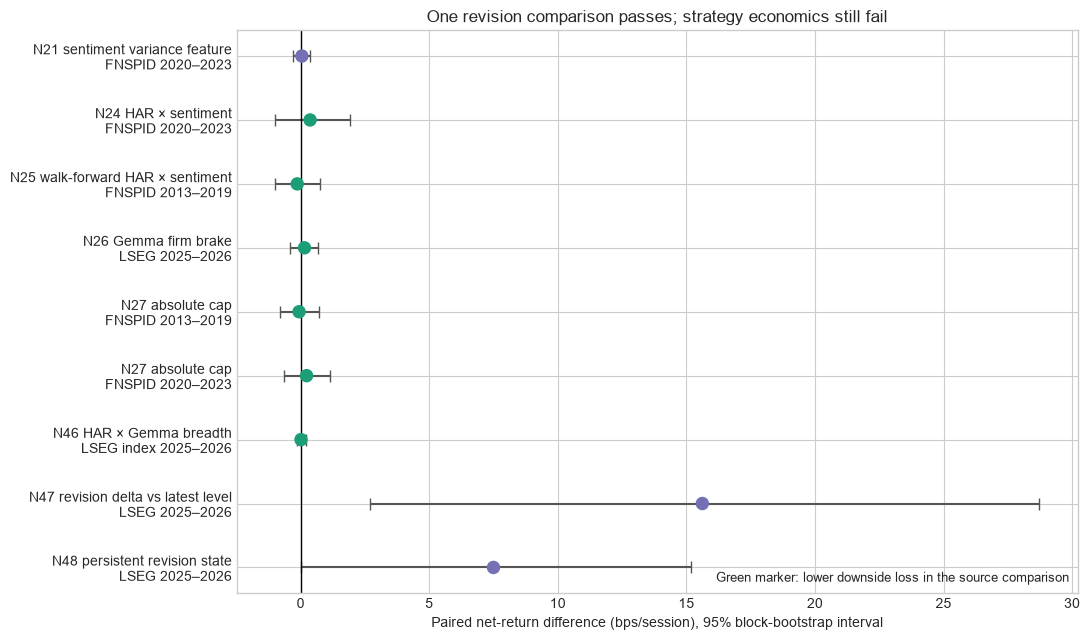

In [6]:
fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(overlays))
means = overlays["return_difference_bps_session"].to_numpy()
lows = overlays["return_ci_low_bps_session"].to_numpy()
highs = overlays["return_ci_high_bps_session"].to_numpy()
point_colors = np.where(overlays["downside_improves"], "#1b9e77", "#7570b3")
ax.errorbar(means, y, xerr=[means - lows, highs - means], fmt="none", ecolor="#555555", capsize=4, lw=1.5)
ax.scatter(means, y, c=point_colors, s=75, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(
    y,
    [
        f"{comparison}\n{regime}"
        for comparison, regime in zip(
            overlays["comparison"], overlays["regime"], strict=True
        )
    ],
)
ax.invert_yaxis()
ax.set_xlabel("Paired net-return difference (bps/session), 95% block-bootstrap interval")
ax.set_title("One revision comparison passes; strategy economics still fail")
ax.text(
    0.99, 0.02, "Green marker: lower downside loss in the source comparison",
    transform=ax.transAxes, ha="right", fontsize=9,
)
fig.tight_layout()
fig.savefig(OUTPUT / "paired_sentiment_overlay_returns.png", dpi=180, bbox_inches="tight")
plt.show()

## Cross-regime continuous-rule stress test

Notebook 39 chose mean-continuous aggregation without opening returns. The same
construction then produced positive gross performance in the later FNSPID evaluation
block, but weak development economics, negative 2010 performance, and negative direct
LSEG performance. This is evidence that **measurement portability is not economic
portability**.

In [7]:
n40_dev = one(tables["n40_results"], split="development", strategy="adaptive_dispersion")
n43_all = one(tables["n43_results"], strategy="all_headlines")


def transfer_row(label: str, row: pd.Series) -> dict:
    return {
        "regime": label,
        "gross_sharpe": float(row["sharpe_gross"]),
        "net_sharpe": float(row["sharpe_net"]),
        "gross_total_return": float(row["total_return_gross"]),
        "net_total_return": float(row["total_return_net"]),
        "breakeven_bps_per_side": float(row["breakeven_bps_per_side"]),
    }


transfer = pd.DataFrame(
    [
        transfer_row("FNSPID development", n40_dev),
        transfer_row("FNSPID evaluation", n40_eval),
        transfer_row("FNSPID 2010", n42_adaptive),
        transfer_row("LSEG all headlines", n43_all),
        transfer_row("LSEG first release", n43_filtered),
    ]
)
transfer["gross_positive"] = transfer["gross_sharpe"] > 0
transfer["net_positive"] = transfer["net_sharpe"] > 0
assert not transfer["net_positive"].any()
assert (transfer["gross_positive"].sum() == 2)
transfer.to_csv(OUTPUT / "continuous_rule_cross_regime.csv", index=False)
display(transfer.style.format({
    "gross_sharpe": "{:+.3f}", "net_sharpe": "{:+.3f}",
    "gross_total_return": "{:+.1%}", "net_total_return": "{:+.1%}",
    "breakeven_bps_per_side": "{:+.3f}",
}))

,regime,gross_sharpe,net_sharpe,gross_total_return,net_total_return,breakeven_bps_per_side,gross_positive,net_positive
0,FNSPID development,+0.187,-3.215,+5.5%,-65.5%,+0.532,True,False
1,FNSPID evaluation,+1.056,-1.103,+27.3%,-23.3%,+4.904,True,False
2,FNSPID 2010,-1.141,-3.397,-5.5%,-15.9%,-4.802,False,False
3,LSEG all headlines,-1.737,-2.635,-12.3%,-18.1%,-18.625,False,False
4,LSEG first release,-1.473,-2.502,-10.3%,-16.8%,-13.908,False,False


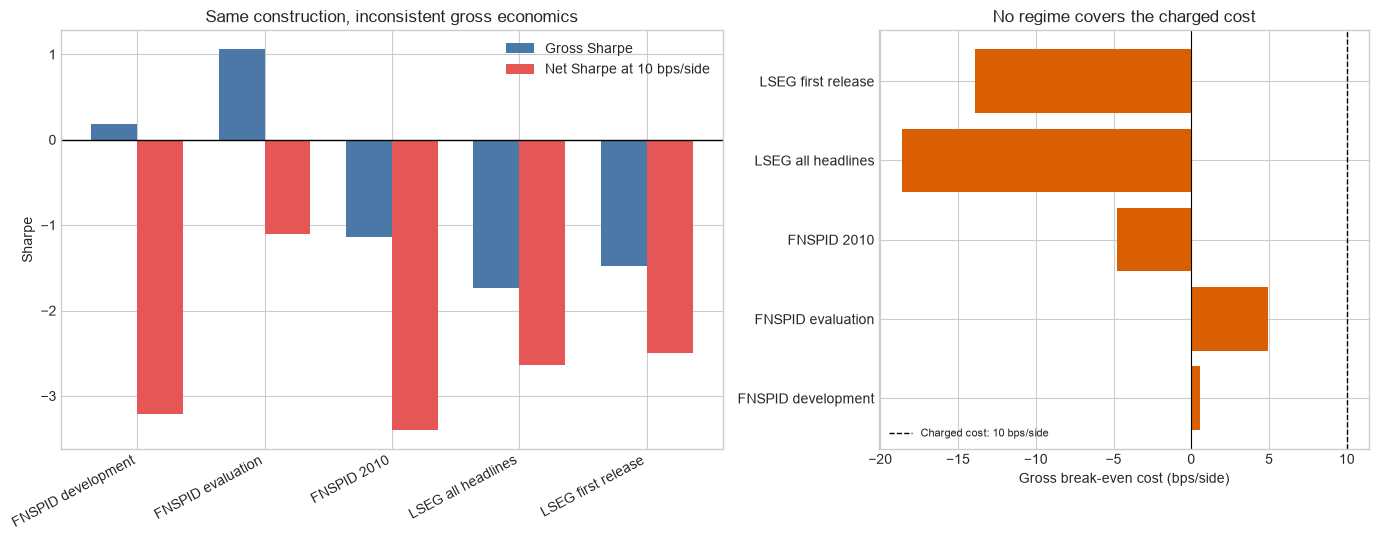

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
x = np.arange(len(transfer))
width = 0.36
axes[0].bar(x - width / 2, transfer["gross_sharpe"], width, label="Gross Sharpe", color="#4c78a8")
axes[0].bar(x + width / 2, transfer["net_sharpe"], width, label="Net Sharpe at 10 bps/side", color="#e45756")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xticks(x, transfer["regime"], rotation=28, ha="right")
axes[0].set_ylabel("Sharpe")
axes[0].set_title("Same construction, inconsistent gross economics")
axes[0].legend()

be_colors = np.where(transfer["breakeven_bps_per_side"] >= 10, "#1b9e77", "#d95f02")
axes[1].barh(transfer["regime"], transfer["breakeven_bps_per_side"], color=be_colors)
axes[1].axvline(10, color="black", ls="--", lw=1, label="Charged cost: 10 bps/side")
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Gross break-even cost (bps/side)")
axes[1].set_title("No regime covers the charged cost")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "continuous_rule_cross_regime.png", dpi=180, bbox_inches="tight")
plt.show()

## Decision

In [9]:
decision = {
    "working_strategy_base": "sentiment-free HAR 10% volatility target as research benchmark only",
    "deployment_qualified_strategy_base": None,
    "base_notebook": 21,
    "base_net_sharpe": float(n21_har["sharpe_net"]),
    "base_net_total_return": float(n21_har["total_return_net"]),
    "base_max_drawdown": float(n21_har["max_drawdown"]),
    "external_time_base_notebook": 46,
    "external_time_base_gate": bool(tables["n46_gates"].iloc[0]["external_time_base_gate"]),
    "external_time_har_net_sharpe": float(n46_har["sharpe_net"]),
    "external_time_constant_net_sharpe": float(n46_constant["sharpe_net"]),
    "external_time_har_total_return": float(n46_har["total_return_net"]),
    "external_time_har_max_drawdown": float(n46_har["max_drawdown"]),
    "sentiment_strategy_promoted": False,
    "sentiment_overlay_return_intervals_excluding_zero": int(overlays["return_ci_excludes_zero"].sum()),
    "sentiment_overlay_comparisons": int(len(overlays)),
    "downside_improvement_comparisons": int(overlays["downside_improves"].sum()),
    "continuous_rule_net_positive_regimes": int(transfer["net_positive"].sum()),
    "continuous_rule_regimes": int(len(transfer)),
    "revision_delta_gross_sharpe": float(n47_revision["sharpe_gross"]),
    "revision_delta_net_sharpe": float(n47_revision["sharpe_net"]),
    "revision_delta_breakeven_bps": float(n47_revision["breakeven_bps_per_side"]),
    "revision_delta_minus_level_bps": float(
        n47_level_comparison["mean_difference"] * 10_000
    ),
    "revision_delta_minus_level_ci_low_bps": float(
        n47_level_comparison["ci_low"] * 10_000
    ),
    "revision_delta_minus_level_ci_high_bps": float(
        n47_level_comparison["ci_high"] * 10_000
    ),
    "persistent_state_net_sharpe": float(n48_state["sharpe_net"]),
    "persistent_state_breakeven_bps": float(n48_state["breakeven_bps_per_side"]),
    "lseg_gemma_role": "non-pooled measurement, downside, and gross revision-information evidence; not validated alpha",
    "strategy_stop_rule": (
        "no expiry, decay, threshold, or holding-period tuning on the opened "
        "revision sample; require genuinely new dates"
    ),
    "gate_f1_status": "evidence input only; final RQ still requires completion or explicit waiver of the human novelty audit",
}

display(Markdown(
    "### Result\n\n"
    "- **Research benchmark:** sentiment-free HAR retains its Notebook 21 result "
    f"(net Sharpe **{decision['base_net_sharpe']:.3f}**, net return "
    f"**{decision['base_net_total_return']:+.1%}**, max drawdown "
    f"**{decision['base_max_drawdown']:.1%}**), but it is not deployment-qualified.\n"
    f"- **External-time base check:** the unchanged HAR transfer has net Sharpe **{decision['external_time_har_net_sharpe']:.3f}** "
    f"versus **{decision['external_time_constant_net_sharpe']:.3f}** for constant matched exposure, return "
    f"**{decision['external_time_har_total_return']:+.1%}**, and drawdown **{decision['external_time_har_max_drawdown']:.1%}**. "
    "Its forecast and strategy gates fail, so there is **no time-stable or deployment-qualified base**.\n"
    "- **Sentiment promotion:** none. "
    f"**{decision['sentiment_overlay_return_intervals_excluding_zero']}/{len(overlays)}** "
    "paired return intervals exclude zero in the favourable direction. The sole pass "
    "is Notebook 47's retrospective revision-delta advantage over a matched latest-level "
    "comparator; the revision strategy itself is net-negative at 10 bps/side.\n"
    f"- **Useful sentiment result:** downside loss improves in **{decision['downside_improvement_comparisons']}/{len(overlays)}** "
    "bounded comparisons across FNSPID and LSEG/Gemma. Notebook 46's improvement "
    "disappears against a constant exposure multiplier, reinforcing mechanical "
    "de-risking rather than semantic timing.\n"
    f"- **Directional-alpha result:** the portable continuous rule is net-positive in **0/{len(transfer)}** tested regime/split rows at "
    "10 bps/side and is gross-negative in both the 2010 backward test and direct LSEG replay.\n"
    "- **Revision-information result:** Notebook 47 has gross/net Sharpe "
    f"**{decision['revision_delta_gross_sharpe']:.3f}/"
    f"{decision['revision_delta_net_sharpe']:.3f}** and beats matched latest-level ranking by "
    f"**{decision['revision_delta_minus_level_bps']:+.3f} bps/session** with interval "
    f"**[{decision['revision_delta_minus_level_ci_low_bps']:+.3f}, "
    f"{decision['revision_delta_minus_level_ci_high_bps']:+.3f}]**, but its break-even is only "
    f"**{decision['revision_delta_breakeven_bps']:.2f} bps/side**. Notebook 48 raises break-even to "
    f"**{decision['persistent_state_breakeven_bps']:.2f} bps/side** through a "
    "parameter-free carry state, yet remains net-negative (Sharpe "
    f"**{decision['persistent_state_net_sharpe']:.3f}**) and unstable at 10 bps.\n"
    "- **Action:** stop historical strategy tuning, including revision expiry, decay, "
    "threshold, and holding-period variants. Keep HAR only as the research "
    "benchmark; any strategy claim now requires a genuinely new-date frozen replay.\n"
    "- **Gate F1:** this is an evidence input, not the RQ decision; the human novelty-audit blocker remains."
))

### Result

- **Research benchmark:** sentiment-free HAR retains its Notebook 21 result (net Sharpe **0.673**, net return **+29.8%**, max drawdown **-15.7%**), but it is not deployment-qualified.
- **External-time base check:** the unchanged HAR transfer has net Sharpe **0.240** versus **0.940** for constant matched exposure, return **+1.2%**, and drawdown **-7.8%**. Its forecast and strategy gates fail, so there is **no time-stable or deployment-qualified base**.
- **Sentiment promotion:** none. **1/9** paired return intervals exclude zero in the favourable direction. The sole pass is Notebook 47's retrospective revision-delta advantage over a matched latest-level comparator; the revision strategy itself is net-negative at 10 bps/side.
- **Useful sentiment result:** downside loss improves in **6/9** bounded comparisons across FNSPID and LSEG/Gemma. Notebook 46's improvement disappears against a constant exposure multiplier, reinforcing mechanical de-risking rather than semantic timing.
- **Directional-alpha result:** the portable continuous rule is net-positive in **0/5** tested regime/split rows at 10 bps/side and is gross-negative in both the 2010 backward test and direct LSEG replay.
- **Revision-information result:** Notebook 47 has gross/net Sharpe **1.523/-1.866** and beats matched latest-level ranking by **+15.620 bps/session** with interval **[+2.683, +28.725]**, but its break-even is only **4.49 bps/side**. Notebook 48 raises break-even to **8.15 bps/side** through a parameter-free carry state, yet remains net-negative (Sharpe **-0.331**) and unstable at 10 bps.
- **Action:** stop historical strategy tuning, including revision expiry, decay, threshold, and holding-period variants. Keep HAR only as the research benchmark; any strategy claim now requires a genuinely new-date frozen replay.
- **Gate F1:** this is an evidence input, not the RQ decision; the human novelty-audit blocker remains.

In [10]:
manifest_paths = [
    "final_experiments/outputs/20_fnspid_market_sentiment_risk_overlay/manifest.json",
    "final_experiments/outputs/21_fnspid_sentiment_volatility_target/manifest.json",
    "final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base/manifest.json",
    "final_experiments/outputs/24_fnspid_har_sentiment_hysteresis/manifest.json",
    "final_experiments/outputs/25_fnspid_har_sentiment_walkforward/manifest.json",
    "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes/manifest.json",
    "final_experiments/outputs/27_fnspid_har_sentiment_composition/manifest.json",
    "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "final_experiments/outputs/40_fnspid_lseg_gemma_continuous_rule_transfer/manifest.json",
    "final_experiments/outputs/42_fnspid_2010_preperiod_transfer/manifest.json",
    "final_experiments/outputs/43_lseg_gemma_story_family_first_release/manifest.json",
    "final_experiments/outputs/46_lseg_external_time_har_base_transfer/manifest.json",
    "final_experiments/outputs/47_lseg_gemma_story_revision_delta/manifest.json",
    "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/manifest.json",
]
source_manifests = {path: read_json(path) for path in manifest_paths}

manifest = {
    "notebook": "44_strategy_evidence_synthesis.ipynb",
    "status": "complete_aggregate_only_strategy_synthesis_updated_through_n48",
    "seed": SEED,
    "git_commit_at_execution": git_commit(),
    "input_boundary": {
        "aggregate_csv_files": paths,
        "source_manifest_paths": manifest_paths,
        "source_sha256": {path: sha256(path) for path in [*paths.values(), *manifest_paths]},
        "row_level_returns_loaded": False,
        "prices_loaded": False,
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
    },
    "evidence_policy": {
        "ordinal_only": True,
        "sentiment_promotion_requires": [
            "paired net-return interval favourable and excludes zero",
            "temporal stability",
            "local predeclared gate passes",
            "evidence score at least 4",
        ],
        "cross_regime_sharpe_directly_comparable": False,
        "p_values_meta_analysed": False,
    },
    "counts": {
        "registry_rows": int(len(registry)),
        "decision_eligible_rows": int(registry["decision_eligible"].sum()),
        "sentiment_overlay_rows": int(len(overlays)),
        "favourable_return_intervals_excluding_zero": int(overlays["return_ci_excludes_zero"].sum()),
        "downside_improvement_rows": int(overlays["downside_improves"].sum()),
        "continuous_transfer_rows": int(len(transfer)),
        "continuous_net_positive_rows": int(transfer["net_positive"].sum()),
    },
    "decision": decision,
    "limitations": [
        "The evidence tier is a governance aid, not a statistical weight.",
        "Sharpe ratios span different dates, universes, costs, and selection histories and are not pooled.",
        "Overlay tests overlap and their p-values are not independent; no meta-analysis is performed.",
        "The HAR base remains a conventional research benchmark, but Notebook 46 rejects time-stable deployment qualification.",
        "Notebook 47's sole favourable return interval is a retrospective construction comparison, not cash alpha.",
        "Notebook 48 reduces turnover without clearing the frozen 10-bps cost or temporal-stability gates.",
        "Gate F1 remains blocked on completion or explicit waiver of the human novelty audit.",
    ],
}

(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest["decision"], indent=2))

{
  "working_strategy_base": "sentiment-free HAR 10% volatility target as research benchmark only",
  "deployment_qualified_strategy_base": null,
  "base_notebook": 21,
  "base_net_sharpe": 0.6726744786401039,
  "base_net_total_return": 0.2984743689658731,
  "base_max_drawdown": -0.1572999844511723,
  "external_time_base_notebook": 46,
  "external_time_base_gate": false,
  "external_time_har_net_sharpe": 0.2395608408271822,
  "external_time_constant_net_sharpe": 0.9401725121242784,
  "external_time_har_total_return": 0.0124112951314285,
  "external_time_har_max_drawdown": -0.0777036081765966,
  "sentiment_strategy_promoted": false,
  "sentiment_overlay_return_intervals_excluding_zero": 1,
  "sentiment_overlay_comparisons": 9,
  "downside_improvement_comparisons": 6,
  "continuous_rule_net_positive_regimes": 0,
  "continuous_rule_regimes": 5,
  "revision_delta_gross_sharpe": 1.5225140253651817,
  "revision_delta_net_sharpe": -1.8657247395851069,
  "revision_delta_breakeven_bps": 4.48624

## Next step

Use this refreshed notebook as the strategy evidence input to Gate F1. Do not add
another historical rule or tune revision expiry, decay, threshold, or holding period.
HAR is a research comparator, not a deployment-qualified strategy. The only legitimate
strategy follow-up is a genuinely new-date frozen replay.